In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [200]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdelmalekeladjelet/sentiment-analysis-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-dataset


In [201]:
import os
# The correct data file name has been identified as 'sentiment_data.csv'
file_path = os.path.join(path, "sentiment_data.csv")
data = pd.read_csv(file_path)
data.head()


,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [202]:
data.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [203]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


In [204]:
data.isnull().sum()

,0
Unnamed: 0,0
Comment,217
Sentiment,0


In [205]:
print(type(data))

data.dropna(subset=["Comment"], inplace=True)
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
(240928, 3)


In [206]:
data.isnull().sum()

,0
Unnamed: 0,0
Comment,0
Sentiment,0


In [207]:
data['Sentiment'].unique()

array([1, 0, 2])

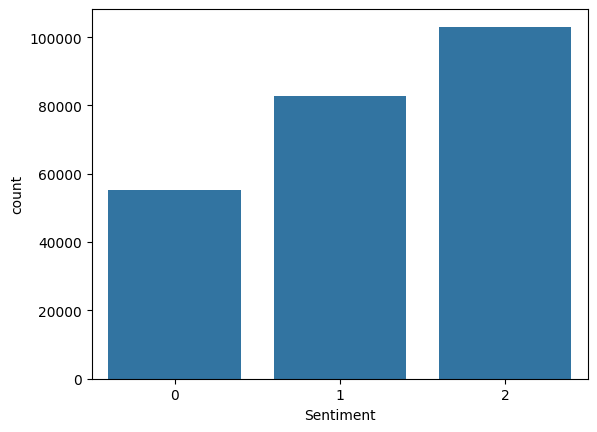

In [208]:
sns.countplot(x=data['Sentiment'])
plt.show()

In [209]:
import re
def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [210]:
data["Comment"] = data["Comment"].apply(clean_text)

In [211]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [212]:
vocab_size=50000
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token ="<OOV>"
)
tokenizer.fit_on_texts(data['Comment'])

In [213]:
data['text_sequences'] = tokenizer.texts_to_sequences(data['Comment'])

In [214]:
for word,index in tokenizer.word_index.items():
  print(word,index)
  if index ==10:
    break

<OOV> 1
modi 2
india 3
like 4
people 5
bjp 6
one 7
congress 8
dont 9
time 10


In [215]:
vocab_size = len(tokenizer.word_index)

In [216]:
data.head()

,Unnamed: 0,Comment,Sentiment,text_sequences
0,0,lets forget apple pay required brand new iphon...,1,"[399, 429, 1243, 416, 1398, 1648, 39, 1432, 64..."
1,1,nz retailers don’t even contactless credit car...,0,"[14404, 22309, 1660, 17, 1, 68, 846, 5101, 4, ..."
2,2,forever acknowledge channel help lessons ideas...,2,"[1032, 3793, 433, 149, 3323, 1258, 5799, 649, ..."
3,3,whenever go place doesn’t take apple pay doesn...,0,"[1411, 111, 352, 3981, 58, 1243, 416, 3981, 42..."
4,4,apple pay convenient secure easy use used kore...,2,"[1243, 416, 4909, 1780, 426, 106, 167, 6953, 6..."


In [217]:
from collections import Counter

sequence_lengths = [len(seq) for seq in data['text_sequences']]

length_counts = Counter(sequence_lengths)

lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [218]:
length_counts.most_common(5)

[(6, 14158), (7, 14092), (8, 13943), (5, 13523), (9, 13359)]

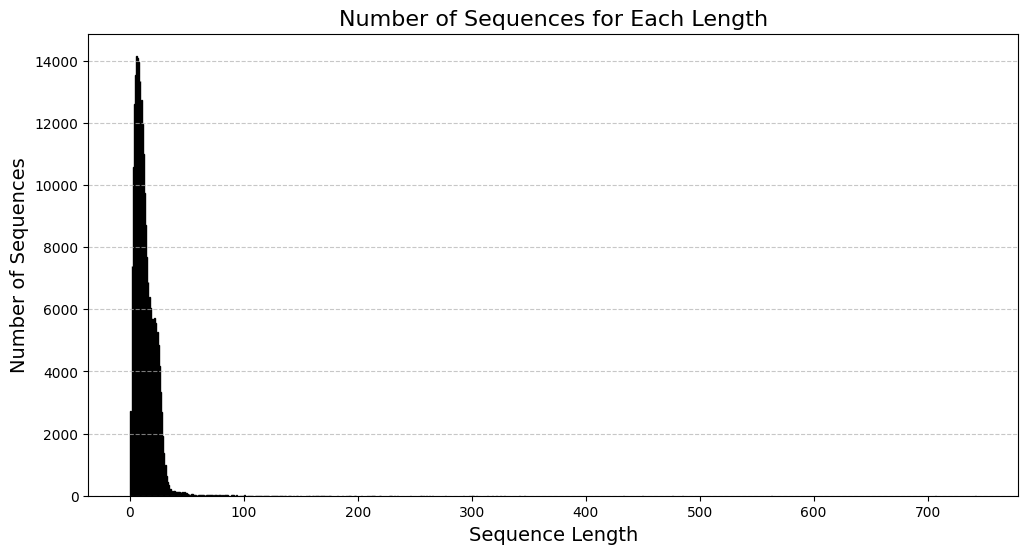

In [219]:
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')
plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [220]:
input_shape = 50

In [221]:
from tensorflow import keras
from keras.preprocessing.sequence import pad_sequences
X = pad_sequences(
    data['text_sequences'],
    maxlen=input_shape,
    padding='post',
    truncating='post'
)

In [222]:
y = data['Sentiment'].astype(int).values

In [223]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=100) # encoded_matrix
print("X_train : \n",X_train)
print("X_test  : \n",X_test)

X_train : 
 [[ 7736   493    49 ...     0     0     0]
 [    2   757   188 ...     0     0     0]
 [  362   456    45 ...     0     0     0]
 ...
 [  220 20047  7275 ...     0     0     0]
 [   12   334   180 ...     0     0     0]
 [   40   280     1 ...     0     0     0]]
X_test  : 
 [[ 8833     1   913 ...     0     0     0]
 [    1 19364  7055 ...     0     0     0]
 [ 3089  3153   113 ...     0     0     0]
 ...
 [  898   471  1521 ...     0     0     0]
 [  651  1624    10 ...     0     0     0]
 [  172   719     0 ...     0     0     0]]


In [224]:
print("X_train shape : ",X_train.shape)
print("y_train shape : ",y_train.shape)
print("X_test  shape : ",X_test.shape)

X_train shape :  (192742, 50)
y_train shape :  (192742,)
X_test  shape :  (48186, 50)


In [225]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

def get_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                                         restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                             patience=2, min_lr=1e-6)
    ]

Class weights: {0: np.float64(1.4603658074585928), 1: np.float64(0.9703862574512647), 2: np.float64(0.7783781600839996)}


**LSTM**

In [157]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size + 1, output_dim=64,
                              input_length=input_shape),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
], name="LSTM_Model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [158]:
print(model.summary())

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [159]:
model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=tf.keras.optimizers.Adam(1e-3),
                   metrics=['accuracy'])



history = model.fit(X_train, y_train,
                               epochs=25, batch_size=64,
                               validation_split=0.2,
                               class_weight=class_weight_dict,
                               callbacks=get_callbacks())


Epoch 1/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 46s 18ms/step - accuracy: 0.6526 - loss: 0.7942 - val_accuracy: 0.7720 - val_loss: 0.6138 - learning_rate: 0.0010
Epoch 2/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.8053 - loss: 0.5306 - val_accuracy: 0.8217 - val_loss: 0.4907 - learning_rate: 0.0010
Epoch 3/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.8538 - loss: 0.4134 - val_accuracy: 0.8319 - val_loss: 0.4605 - learning_rate: 0.0010
Epoch 4/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.8829 - loss: 0.3423 - val_accuracy: 0.8341 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 5/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9046 - loss: 0.2856 - val_accuracy: 0.8231 - val_loss: 0.5412 - learning_rate: 0.0010
Epoch 6/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9299 - loss: 0.2146 - val_accuracy: 0.8366 - val_loss: 0.5576 - learning_rate: 3.0000e-04
Epoch 7/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - ac

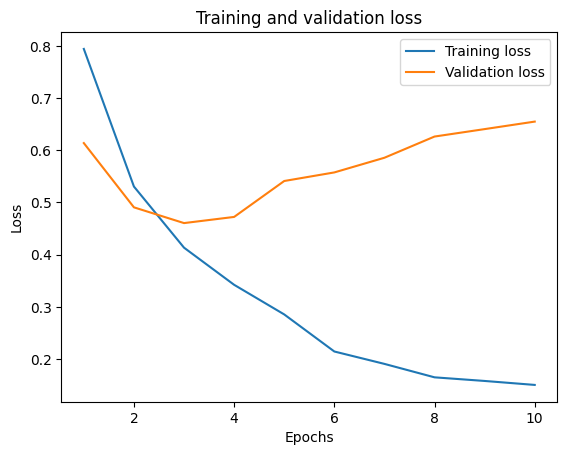

In [160]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

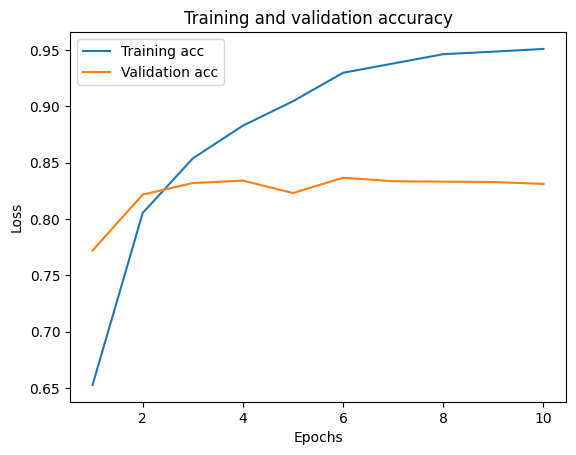

In [161]:
plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [162]:
y_pred = model.predict(X_test).argmax(axis=-1).tolist()

class_names = ['Negative', 'Neutral', 'Positive']

from sklearn.metrics import classification_report, confusion_matrix
print("Classification report:\n", classification_report(y_test, y_pred, target_names=class_names))

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Classification report:
               precision    recall  f1-score   support

    Negative       0.78      0.79      0.78     11111
     Neutral       0.83      0.84      0.84     16569
    Positive       0.87      0.86      0.87     20506

    accuracy                           0.84     48186
   macro avg       0.83      0.83      0.83     48186
weighted avg       0.84      0.84      0.84     48186



Confusion matrix : 



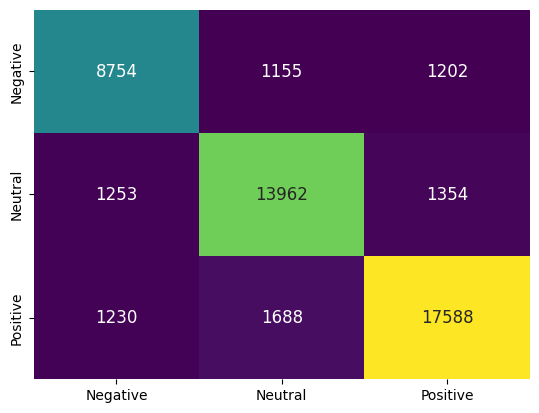

Normalized confusion matrix : 



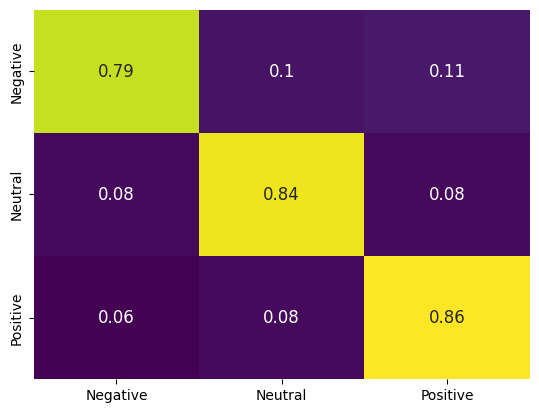

In [163]:
def draw_confusion_matrix(true,preds,normalize=None):
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)

  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")



**GRU**

In [226]:
tf.keras.backend.clear_session()

In [227]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size + 1, output_dim=64,
                              input_length=input_shape),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
], name="GRU_Model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [228]:
print(model.summary())

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [229]:
model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=tf.keras.optimizers.Adam(1e-3),
                   metrics=['accuracy'])



history = model.fit(X_train, y_train,
                               epochs=25, batch_size=64,
                               validation_split=0.2,
                               class_weight=class_weight_dict,
                               callbacks=get_callbacks())


Epoch 1/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 45s 18ms/step - accuracy: 0.3237 - loss: 1.0991 - val_accuracy: 0.4291 - val_loss: 1.0902 - learning_rate: 0.0010
Epoch 2/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.3370 - loss: 1.0985 - val_accuracy: 0.4295 - val_loss: 1.0982 - learning_rate: 0.0010
Epoch 3/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.4065 - loss: 1.0613 - val_accuracy: 0.6989 - val_loss: 0.7440 - learning_rate: 0.0010
Epoch 4/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.7698 - loss: 0.6016 - val_accuracy: 0.8243 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 5/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8514 - loss: 0.4229 - val_accuracy: 0.8322 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 6/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.8853 - loss: 0.3359 - val_accuracy: 0.8428 - val_loss: 0.4472 - learning_rate: 0.0010
Epoch 7/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accura

In [230]:
y_pred = model.predict(X_test).argmax(axis=-1).tolist()

class_names = ['Negative', 'Neutral', 'Positive']

from sklearn.metrics import classification_report, confusion_matrix
print("Classification report:\n", classification_report(y_test, y_pred, target_names=class_names))

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Classification report:
               precision    recall  f1-score   support

    Negative       0.79      0.79      0.79     11111
     Neutral       0.82      0.87      0.84     16569
    Positive       0.89      0.85      0.87     20506

    accuracy                           0.84     48186
   macro avg       0.84      0.84      0.84     48186
weighted avg       0.84      0.84      0.84     48186



Confusion matrix : 



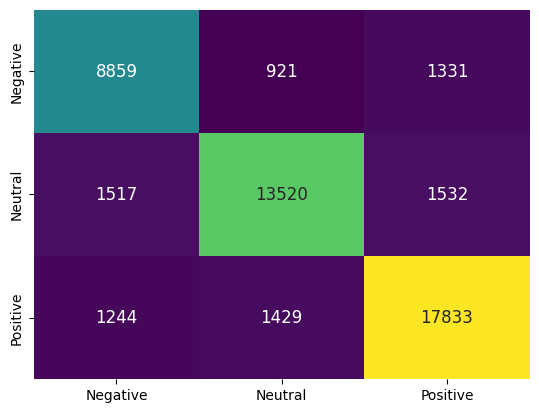

Normalized confusion matrix : 



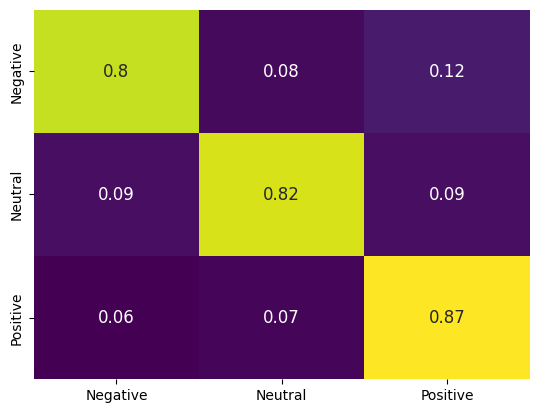

In [69]:
def draw_confusion_matrix(true,preds,normalize=None):
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)

  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")


**Bidirectional LSTM**

In [96]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size + 1, output_dim=64,
                              input_length=input_shape),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
], name="BiLSTM_Model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [97]:
print(model.summary())

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [98]:
model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=tf.keras.optimizers.Adam(1e-3),
                   metrics=['accuracy'])



history = model.fit(X_train, y_train,
                               epochs=25, batch_size=64,
                               validation_split=0.2,
                               class_weight=class_weight_dict,
                               callbacks=get_callbacks())


Epoch 1/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 63s 24ms/step - accuracy: 0.7635 - loss: 0.5991 - val_accuracy: 0.8372 - val_loss: 0.4410 - learning_rate: 0.0010
Epoch 2/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8558 - loss: 0.4075 - val_accuracy: 0.8400 - val_loss: 0.4419 - learning_rate: 0.0010
Epoch 3/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - accuracy: 0.8896 - loss: 0.3228 - val_accuracy: 0.8487 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 4/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.9263 - loss: 0.2192 - val_accuracy: 0.8489 - val_loss: 0.5173 - learning_rate: 3.0000e-04
Epoch 5/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.9385 - loss: 0.1826 - val_accuracy: 0.8470 - val_loss: 0.5590 - learning_rate: 3.0000e-04
Epoch 6/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - accuracy: 0.9504 - loss: 0.1467 - val_accuracy: 0.8451 - val_loss: 0.6317 - learning_rate: 9.0000e-05
Epoch 7/25
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/s

In [99]:
y_pred = model.predict(X_test).argmax(axis=-1).tolist()

class_names = ['Negative', 'Neutral', 'Positive']

from sklearn.metrics import classification_report, confusion_matrix
print("Classification report:\n", classification_report(y_test, y_pred, target_names=class_names))

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
Classification report:
               precision    recall  f1-score   support

    Negative       0.78      0.82      0.80     11111
     Neutral       0.84      0.84      0.84     16569
    Positive       0.89      0.86      0.87     20506

    accuracy                           0.84     48186
   macro avg       0.84      0.84      0.84     48186
weighted avg       0.85      0.84      0.85     48186



Confusion matrix : 



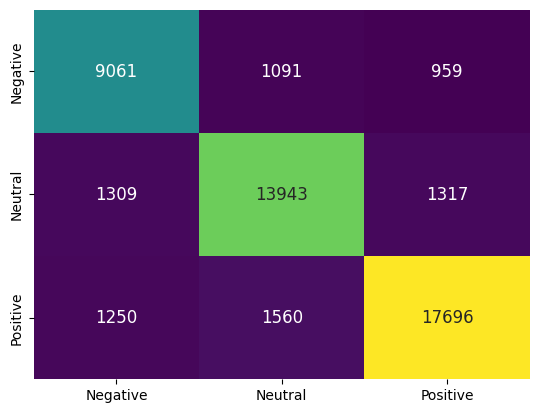

Normalized confusion matrix : 



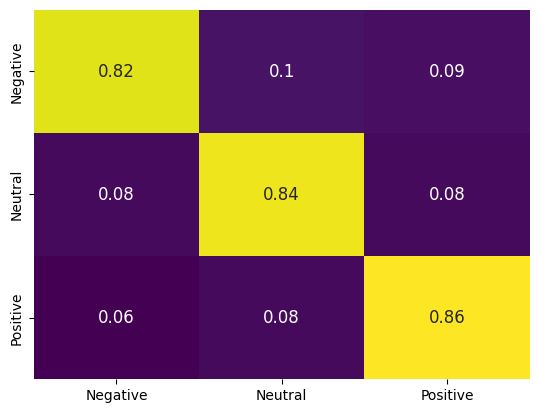

In [100]:
def draw_confusion_matrix(true,preds,normalize=None):
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)

  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")